In [2]:
import config
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import utils

In [3]:
fig_save_path = Path("figures")
fig_save_path.mkdir(exist_ok=True)

In [4]:
# Load the OneStopQA dataset
onestop_qa = load_dataset(
    "onestop_qa", split="train", trust_remote_code=True
).to_pandas()

In [5]:
QUESTIONNAIRE = utils.load_json(config.QUESTIONNAIRE_PATH)
SESSION_SUMMARY = utils.load_df(config.SESSION_SUMMARY_PATH)
FULL_REPORT = pd.read_csv(config.FULL_REPORT_PATH)

In [6]:
IA_P = utils.load_df(config.IA_P_PATH)
IA_Q = utils.load_df(config.IA_Q_PATH)
IA_A = utils.load_df(config.IA_A_PATH)
IA_Q_preview = utils.load_df(config.IA_Q_preview_PATH)
IA_T = utils.load_df(config.IA_T_PATH)
IA_QA = utils.load_df(config.IA_QA_PATH)

# 1.1.1 Key Statistics

In [7]:
# Calculate the lengths
p = len(IA_P)
q = len(IA_Q)
a = len(IA_A)
qa = len(IA_QA)
q_pre = len(IA_Q_preview)
t = len(IA_T)
total = p + q + a + t + q_pre

# Consolidated print statement
print(
    f"Number of tokens in IA reports:\nparagraphs - {p}\nquestions - {q}\nquestions and answers - {qa}\nquestions preview - {q_pre}\ntitles - {t}\ntotal words - {total}"
)

Number of tokens in IA reports:
paragraphs - 977531
questions - 92825
questions and answers - 461490
questions preview - 36363
titles - 14403
total words - 1489787


# 1.1.2 Participants

In [8]:
# remove from fullreport lines with no RECORDING_SESSION_LABEL
full_report = FULL_REPORT.dropna(subset=["RECORDING_SESSION_LABEL"])
session_summary = SESSION_SUMMARY.dropna(subset=["participant_id"])
metadata = pd.read_csv(config.METADATA_PATH)
# for each line full_report add ONLY columns (Survey notes, L1, LEXTALE, Mich-Test, Date) from metadata
metadata_col = metadata[["ID", "Survey notes", "L1", "LEXTALE", "Mich-Test", "Date"]]
metadata_col = metadata_col.dropna(subset=["ID"])
full_report = pd.merge(full_report, metadata_col, on="ID", how="left")
# change the name of the column ID to participant_id in metadata_col
metadata_col = metadata_col.rename(columns={"ID": "participant_id"})
session_summary = pd.merge(session_summary, metadata_col, on="participant_id", how="left")




In [45]:
print(f"Total number of participants: {len(full_report)}")
print(f"Total number of participants: {len(session_summary)}")

Total number of participants: 137
Total number of participants: 137


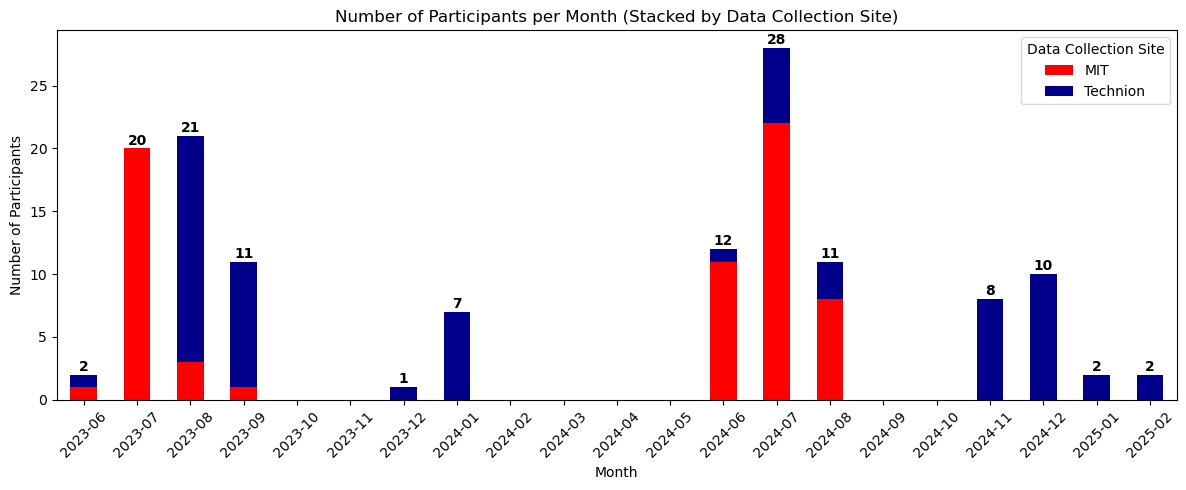

In [9]:


# Define custom colors for MIT and Technion
custom_colors = {"MIT": "red", "Technion": "darkblue"}

# Convert Date to datetime if not null
session_summary["Date"] = pd.to_datetime(session_summary["Date"], errors="coerce")
session_summary["month"] = session_summary["Date"].dt.to_period("M")

# Convert month to string explicitly to ensure compatibility with plotting functions
session_summary["month"] = session_summary["month"].astype(str)

#remove missing values
session_summary_135 = session_summary.dropna(subset=["Date"])

# Ensure x-axis contains all months in sequence, even if some months have no data
all_months_df = pd.DataFrame({"month": pd.period_range(
    start=session_summary_135["month"].min(),
    end=session_summary_135["month"].max(),
    freq="M"
).astype(str)})

# Sort data by month
session_summary_135 = session_summary_135.sort_values(by="month")

# Merge to ensure all months exist with zero counts if missing
session_summary_135_complete = all_months_df.merge(
    session_summary_135.groupby(["month", "data_collection_site"]).size().reset_index(name="count"),
    on="month",
    how="left"
).fillna(0)  # Fill missing months with zero counts

# Convert count column to integer
session_summary_135_complete["count"] = session_summary_135_complete["count"].astype(int)

# Pivot the data to make it suitable for stacked plotting
session_summary_pivot = session_summary_135_complete.pivot(index="month", columns="data_collection_site", values="count").fillna(0)


# Plot using barplot for correct x-axis alignment
fig, ax = plt.subplots(figsize=(12, 5))

session_summary_pivot.plot(
    kind="bar",
    stacked=True,
    color=[custom_colors.get(col, "gray") for col in session_summary_pivot.columns],
    ax=ax
)

# Annotate total participants per month above the bars
for i, total in enumerate(session_summary_pivot.sum(axis=1)):
    if total > 0:  # Avoid annotating zero values
        ax.text(i, total + 0.3, str(int(total)), ha="center", fontsize=10, fontweight="bold")


plt.xticks(rotation=45)
plt.title("Number of Participants per Month (Stacked by Data Collection Site)")
plt.xlabel("Month")
plt.ylabel("Number of Participants")

# Remove "0" from the legend
handles, labels = ax.get_legend_handles_labels()
filtered_handles_labels = [(h, l) for h, l in zip(handles, labels) if l != "0"]
ax.legend(*zip(*filtered_handles_labels), title="Data Collection Site")

plt.tight_layout()

plt.savefig(fig_save_path / "participants_per_month.png")

plt.show()



In [18]:
# print the number of participants per site per month
#print(session_summary_135_complete)
# print the number of participants per site per month from metadata
# Convert Date to datetime if not null
metadata2 = metadata
metadata2["Date"] = pd.to_datetime(metadata2["Date"], errors="coerce")
metadata2["month"] = metadata2["Date"].dt.to_period("M")

# Convert month to string explicitly to ensure compatibility with plotting functions
metadata2["month"] = metadata2["month"].astype(str)

#remove missing values
metadata2 = metadata2.dropna(subset=["Date"])
# Merge to ensure all months exist with zero counts if missing
metadata2 = all_months_df.merge(
    metadata2.groupby(["month", "Experimenter"]).size().reset_index(name="count"),
    on="month",
    how="left"
).fillna(0)  # Fill missing months with zero counts

# Convert count column to integer
metadata2["count"] = metadata2["count"].astype(int)

# Pivot the data to make it suitable for stacked plotting
metadata3 = metadata2.pivot(index="month", columns="Experimenter", values="count").fillna(0)

# show only the months with participants
metadata3 = metadata3.loc[metadata3.sum(axis=1) > 0]

#remove experimenters Liz, Aya, Ella, Keren, Raquel
metadata3 = metadata3.drop(columns=["Liz", "Aya", "Ella", "Keren", "Raquel", "Dima"])
metadata3 = metadata3.fillna(0)
print(metadata3)

Experimenter    0   Liz  Diego  Jessica  Marisa  Mindy  Shrey
month                                                        
2023-06       0.0   0.0    0.0      0.0     1.0    0.0    0.0
2023-07       0.0   0.0    1.0      0.0    20.0    0.0    0.0
2023-08       0.0   0.0    2.0      0.0     1.0    0.0    0.0
2023-09       0.0   1.0    0.0      0.0     0.0    0.0    0.0
2023-12       0.0   0.0    0.0      0.0     0.0    0.0    0.0
2024-01       0.0   0.0    0.0      0.0     0.0    0.0    0.0
2024-06       0.0   0.0    0.0      6.0     0.0    3.0    4.0
2024-07       0.0   0.0    0.0     11.0     0.0    3.0   12.0
2024-08       0.0   0.0    0.0      6.0     0.0    0.0    4.0
2024-11       0.0   0.0    0.0      0.0     0.0    0.0    0.0
2024-12       0.0   0.0    0.0      0.0     0.0    0.0    0.0
2025-01       0.0   0.0    0.0      0.0     0.0    0.0    0.0
2025-02       0.0   0.0    0.0      0.0     0.0    0.0    0.0


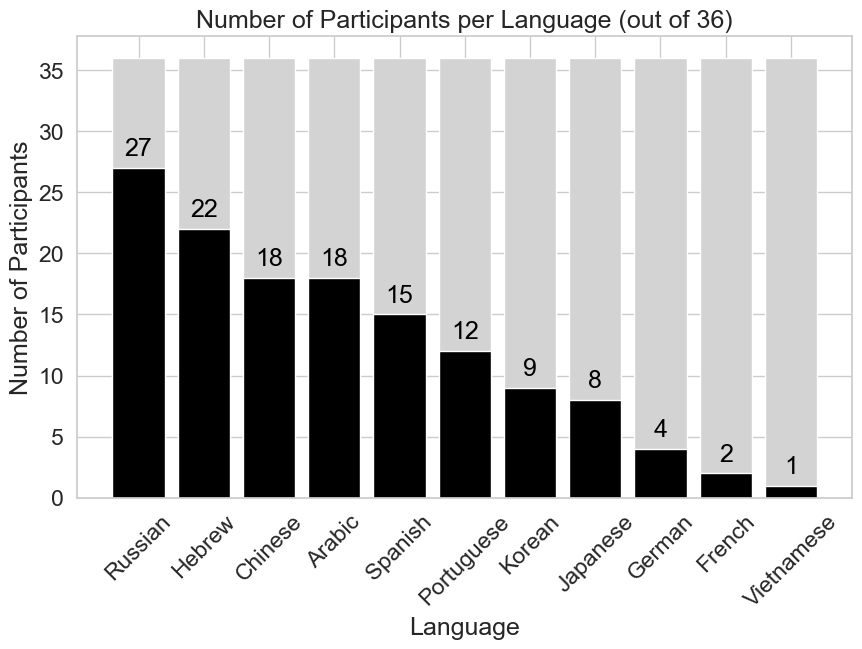

In [47]:
all_languages = ["Hebrew", "Spanish", "German", "French", "Chinese", "Russian", "Korean", "Arabic", "Portuguese", "Japanese", "Vietnamese"]

# Count number of participants per language
language_counts = full_report["L1"].value_counts().reindex(all_languages, fill_value=0)

# Ensure the bars are arranged from highest to lowest
language_counts = language_counts.sort_values(ascending=False)

# Define total participants per language
total_participants = 36

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the total participants as a light background bar
ax.bar(language_counts.index, [total_participants] * len(language_counts), color="lightgray")

# Plot the actual participant counts as a dark-colored bar on top
ax.bar(language_counts.index, language_counts, color="black")

# Add labels
ax.set_title("Number of Participants per Language (out of 36)")
ax.set_ylabel("Number of Participants")
ax.set_xlabel("Language")
plt.xticks(rotation=45)

# Add text labels for actual counts
for i, v in enumerate(language_counts):
    ax.text(i, v + 1, str(v), ha="center", color="black")

# Show plot
plt.show()
fig.savefig(fig_save_path / "participants_per_language.png")





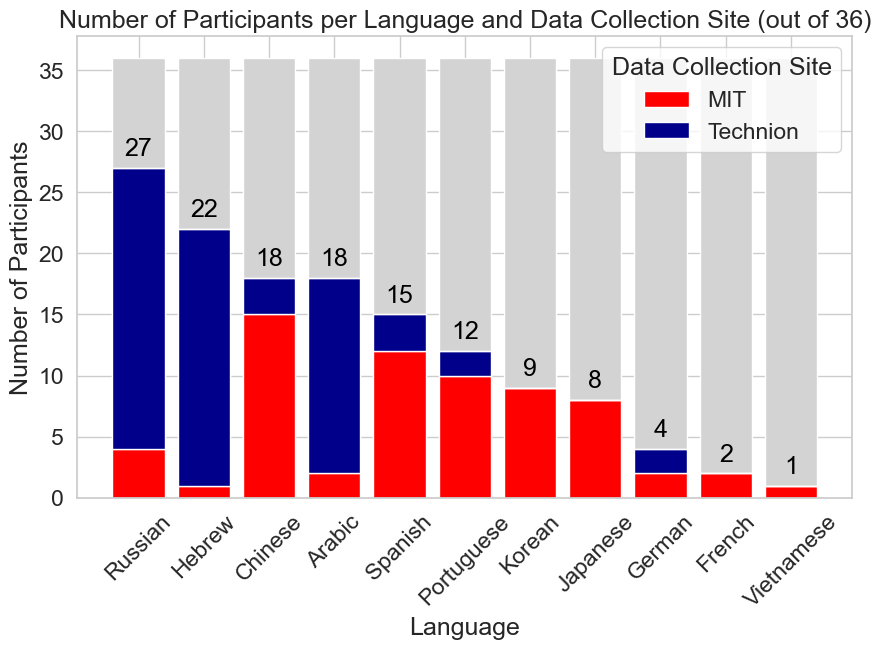

In [ ]:
# Define custom colors for MIT and Technion
custom_colors = {"MIT": "red", "Technion": "darkblue"}

# Plot participants per language as above but with each language split to data_collection_site (stacked)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the total participants as a light background bar
ax.bar(language_counts.index, [total_participants] * len(language_counts), color="lightgray")

# Plot the actual participant counts as a dark-colored bar on top
bottom = np.zeros(len(language_counts))

for i, site in enumerate(session_summary["data_collection_site"].unique()):
    site_counts = session_summary[session_summary["data_collection_site"] == site]["L1"].value_counts().reindex(language_counts.index, fill_value=0)
    ax.bar(language_counts.index, site_counts, bottom=bottom, color=custom_colors.get(site, "gray"), label=site)
    bottom += site_counts

# Add labels
ax.set_title("Number of Participants per Language and Data Collection Site (out of 36)")
ax.set_ylabel("Number of Participants")
ax.set_xlabel("Language")
plt.xticks(rotation=45)

# Add text labels for actual counts
for i, v in enumerate(language_counts):
    ax.text(i, v + 1, str(v), ha="center", color="black")

# Show plot
plt.legend(title="Data Collection Site")
plt.show()

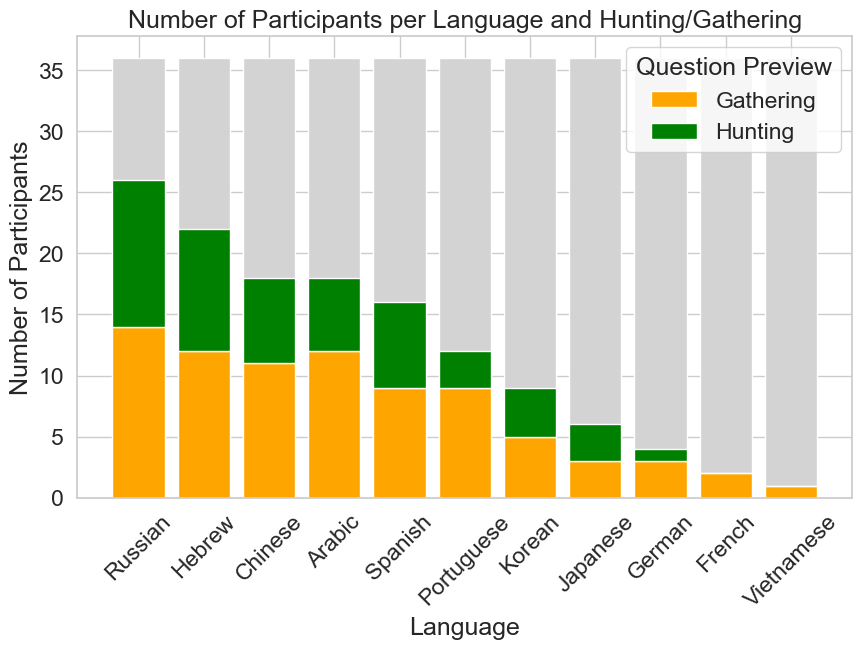

In [169]:
# Define custom colors for Hunting and Gathering
custom_colors = {"Hunting": "green", "Gathering": "orange"}

# Map True/False to Hunting/Gathering
session_summary_135["question_preview"] = session_summary_135["question_preview"].map({True: "Hunting", False: "Gathering"})

# Plot participants per language as above but with each language split to question_preview (stacked)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the total participants as a light background bar
ax.bar(language_counts.index, [total_participants] * len(language_counts), color="lightgray")

# Plot the actual participant counts as a dark-colored bar on top
bottom = np.zeros(len(language_counts))

for preview in session_summary_135["question_preview"].unique():
    preview_counts = session_summary_135[session_summary_135["question_preview"] == preview]["L1"].value_counts().reindex(language_counts.index, fill_value=0)
    ax.bar(language_counts.index, preview_counts, bottom=bottom, color=custom_colors.get(preview, "gray"), label=preview)
    bottom += preview_counts

# Add labels
ax.set_title("Number of Participants per Language and Hunting/Gathering")
ax.set_ylabel("Number of Participants")
ax.set_xlabel("Language")
plt.xticks(rotation=45)

# Add legend
plt.legend(title="Question Preview")

# Show plot
plt.show()



/Users/ellalion/miniforge3/envs/onestop/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


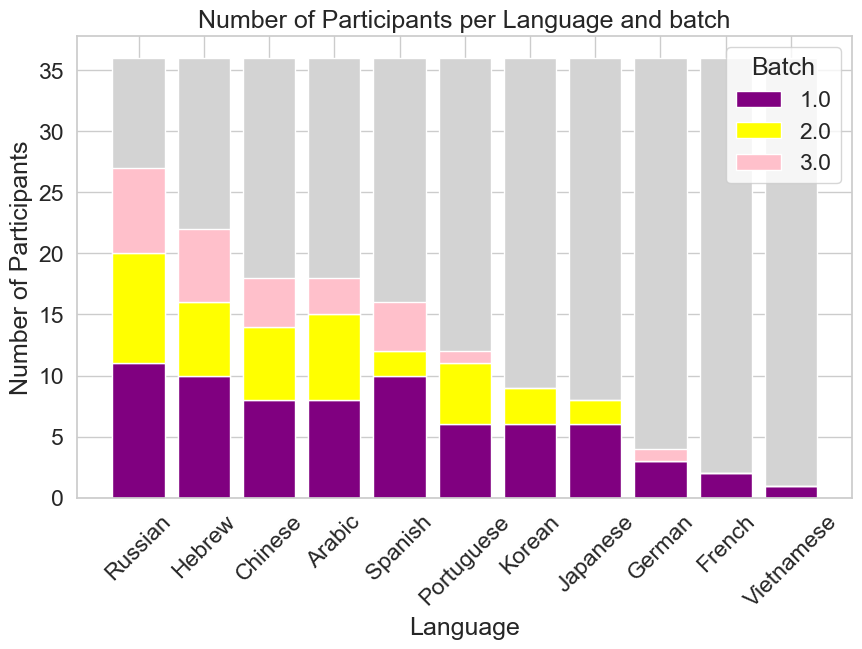

In [172]:
# Define custom colors for True and False
custom_colors = {"1.0": "purple", "2.0": "yellow", "3.0": "pink"}

# Plot participants per language as above but with each language split to question_preview (stacked)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the total participants as a light background bar
ax.bar(language_counts.index, [total_participants] * len(language_counts), color="lightgray")

# Plot the actual participant counts as a dark-colored bar on top
bottom = np.zeros(len(language_counts))

for preview in session_summary["article_batch"].unique():
    preview_counts = session_summary[session_summary["article_batch"] == preview]["L1"].value_counts().reindex(language_counts.index, fill_value=0)
    ax.bar(language_counts.index, preview_counts, bottom=bottom, color=custom_colors.get(str(preview), "gray"), label=str(preview))
    bottom += preview_counts

# Add labels
ax.set_title("Number of Participants per Language and batch")
ax.set_ylabel("Number of Participants")
ax.set_xlabel("Language")
plt.xticks(rotation=45)

# Add legend
plt.legend(title="Batch")

# Show plot
plt.show()

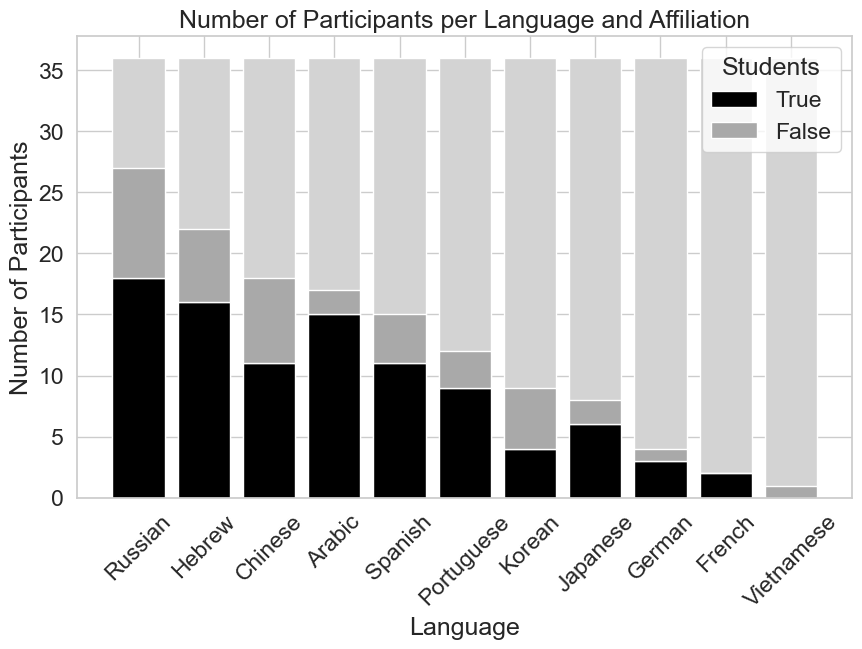

In [175]:
# Define custom colors for True and False
custom_colors = {"True": "black", "False": "darkgray"}

# Filter out None values from the affiliated column
filtered_report = full_report[full_report["affiliated"].notna()]

# Plot participants per language as above but with each language split to question_preview (stacked)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the total participants as a light background bar
ax.bar(language_counts.index, [total_participants] * len(language_counts), color="lightgray")

# Plot the actual participant counts as a dark-colored bar on top
bottom = np.zeros(len(language_counts))

for preview in filtered_report["affiliated"].unique():
    preview_counts = filtered_report[filtered_report["affiliated"] == preview]["L1"].value_counts().reindex(language_counts.index, fill_value=0)
    ax.bar(language_counts.index, preview_counts, bottom=bottom, color=custom_colors.get(str(preview), "gray"), label=str(preview))
    bottom += preview_counts

# Add labels
ax.set_title("Number of Participants per Language and Affiliation")
ax.set_ylabel("Number of Participants")
ax.set_xlabel("Language")
plt.xticks(rotation=45)

# Add legend
plt.legend(title="Students")

# Show plot
plt.show()

/var/folders/xz/v_bn9sxn4ld2lw3b85g8bpmw0000gn/T/ipykernel_90676/365997594.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(language_counts))  # Use a colormap with unique colors


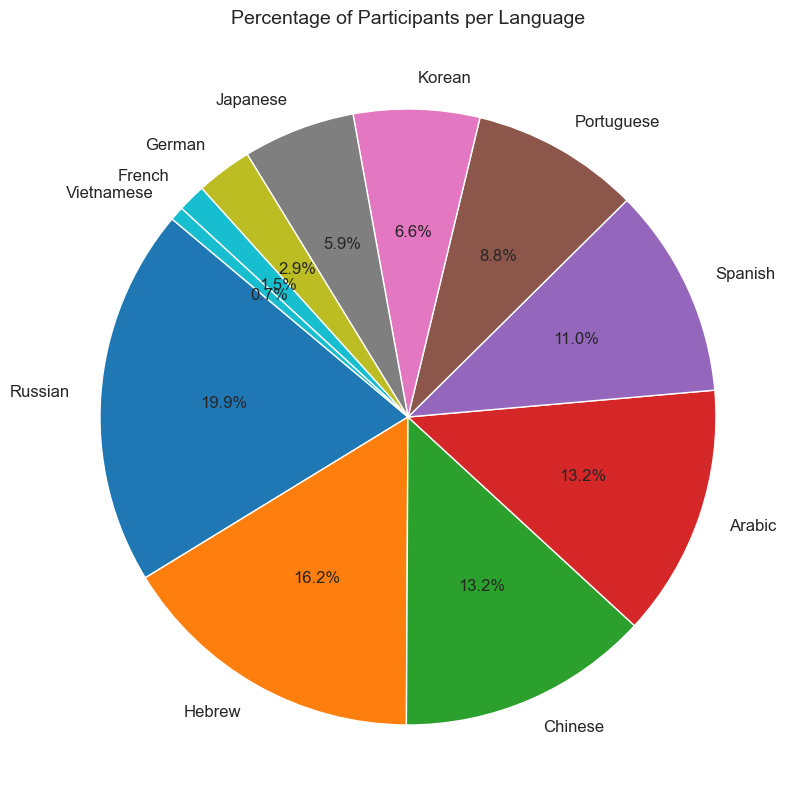

In [49]:
# Define a distinct color for each segment
colors = plt.cm.get_cmap("tab10", len(language_counts))  # Use a colormap with unique colors

# Plot the pie chart
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    language_counts,
    labels=language_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=[colors(i) for i in range(len(language_counts))],  # Assign different colors
    textprops={"fontsize": 12}  # Set default text size
)

# Make percentage labels smaller
for autotext in autotexts:
    autotext.set_fontsize(12)  # Adjust font size of percentage labels

# Add title
ax.set_title("Percentage of Participants per Language", fontsize=14)

# Show plot
plt.show()
fig.savefig(fig_save_path / "participants_per_language_pie.png")

In [111]:
# Questionnaire json to dataframe filled missing values with NaN
questionnaire_df = pd.DataFrame(QUESTIONNAIRE)

# find duplicate participant_id in questionnaire_df and print entaier row of both duplicates in participant_id
duplicate_participant_id = questionnaire_df[questionnaire_df.duplicated(subset=["Participant ID"], keep=False)]["Participant ID"]

# remove duplicate participant_id from questionnaire_df
questionnaire_df = questionnaire_df.drop_duplicates(subset=["Participant ID"], keep="first")



In [112]:
# Eye conditions

eye_cond = questionnaire_df.loc[
    questionnaire_df["Eye Conditions"] == "Yes", ["Eye Condition Details"]
].reset_index(drop=True)

# Apply normalization and get counts
conditions = utils.normalize_eye_conditions(eye_cond, "Eye Condition Details")
conditions["merged"] = (
    conditions["Condition1"].fillna("") + " " + conditions["Condition2"].fillna("")
)
condition_counts = conditions["Normalized Condition"].value_counts()

# Display results
print("Eye Condition Counts:")
print(condition_counts)

Eye Condition Counts:
Normalized Condition
[Lens-Corrected Myopia]                 9
[Astigmatism, Lens-Corrected Myopia]    5
[Astigmatism]                           5
[hypermetropia]                         1
[age related problems in sight ]        1
[miopia]                                1
[myophia]                               1
[Shortsighted]                          1
Name: count, dtype: int64


female - 93, male - 50, other - 1


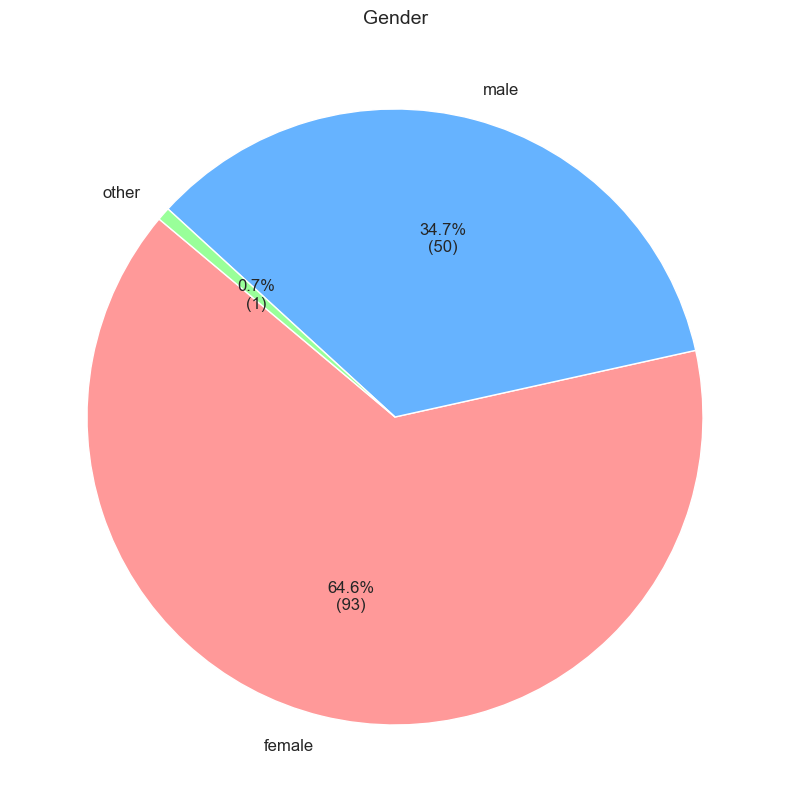

In [128]:
# gender
gender = questionnaire_df["Gender"]
labels, counts = np.unique(gender, return_counts=True)
print(
    f"{labels[0]} - {counts[0]}, {labels[1]} - {counts[1]}, {labels[2]} - {counts[2]}"
)

# Define a function to format the labels with both percentage and count
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:d})"
    return my_format

# Plot gender pie chart with percentage and number of participants
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    autopct=autopct_format(counts),
    startangle=140,
    colors=["#ff9999", "#66b3ff", "#99ff99"],
    textprops={"fontsize": 12},
)

# Make percentage labels smaller
for autotext in autotexts:
    autotext.set_fontsize(12)  # Adjust font size of percentage labels

# Add title
ax.set_title("Gender", fontsize=14)

# Show plot
plt.show()



   
  

In [115]:
print(
    f"Age mean - {round(questionnaire_df['Age'].mean(), ndigits=1)}, \
    Age std - {round(questionnaire_df['Age'].std(), 1)}"
)

#print minimum and maximum age
print(
    f"Age min - {questionnaire_df['Age'].min()}, \
    Age max - {questionnaire_df['Age'].max()}"
)

Age mean - 27.9,     Age std - 7.1
Age min - 18,     Age max - 49


In [63]:
# Balanced Bilinguals
counter = 0
for languages in questionnaire_df["Languages"]:
    if isinstance(languages, list):
        for lang in languages:
            if lang.get("Language Proficiency") == "native":
                counter += 1
print(f"Number of balanced bilinguals: {counter}")

# Number of Additional Languages
par_dict = {}
participants_additional_languages = questionnaire_df["Languages"]
par_languages = []
speak = []
for participant_add_lang in participants_additional_languages:
    if isinstance(participant_add_lang, list):
        for l in participant_add_lang:
            par_languages.append(l.get("Language"))
        speak.append(len(participant_add_lang))
    else:
        participant_add_lang = ""
        speak.append(len(participant_add_lang))
lang, counts = np.unique(par_languages, return_counts=True)
language = dict(zip(lang, counts))
num_of_l, c = np.unique(speak, return_counts=True)
num_of_languages = dict(zip(num_of_l, c))
plus_5 = [min(p_5, 5) for p_5 in speak]
num_of_l_5, c_5 = np.unique(plus_5, return_counts=True)
num_of_lang_plus_5 = dict(zip(num_of_l_5, c_5))

Number of balanced bilinguals: 212


In [116]:
# The mean English Age of Acquisition
print(
    f'Mean age of acquisition (AoA) - {round(np.mean(questionnaire_df["English AoA"]),1)}'
)


Mean age of acquisition (AoA) - 9.4


In [117]:
# participants university affiliation
uni_affiliation = sum(questionnaire_df["University Affiliation"] == "yes")
print(f"Number of participants with university affiliation: {uni_affiliation}")

uni_institutions = questionnaire_df["University Institution"].dropna()
institution_mapping = {
    "mit": "MIT",
    "Technion": "Technion",
}
uni_institutions_grouped = uni_institutions.apply(
    lambda x: institution_mapping.get(x, "Other")
)

institutions_labels, institutions_counts = np.unique(
    uni_institutions_grouped, return_counts=True
)
print("University Institutions and their counts:")
for i_label, i_count in zip(institutions_labels, institutions_counts):
    print(f"{i_label}: {i_count}")

uni_roles = questionnaire_df["University Role"].dropna()
roles_mapping = {
    "undergrad": "Undergrad",
    "grad": "Grad",
    "faculty": "Faculty",
    "admin": "Admin",
}
uni_roles_grouped = uni_roles.apply(lambda x: roles_mapping.get(x, "Other"))
role_labels, role_counts = np.unique(uni_roles_grouped, return_counts=True)
print("University Roles and their counts:")
for r_label, r_count in zip(role_labels, role_counts):
    print(f"{r_label}: {r_count}")

Number of participants with university affiliation: 98
University Institutions and their counts:
MIT: 24
Other: 41
Technion: 33
University Roles and their counts:
Faculty: 10
Grad: 27
Other: 8
Undergrad: 53


/var/folders/xz/v_bn9sxn4ld2lw3b85g8bpmw0000gn/T/ipykernel_90676/2596196557.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set(xticklabels=education_labels)
/var/folders/xz/v_bn9sxn4ld2lw3b85g8bpmw0000gn/T/ipykernel_90676/2596196557.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set(xticklabels=add_lang_labels)


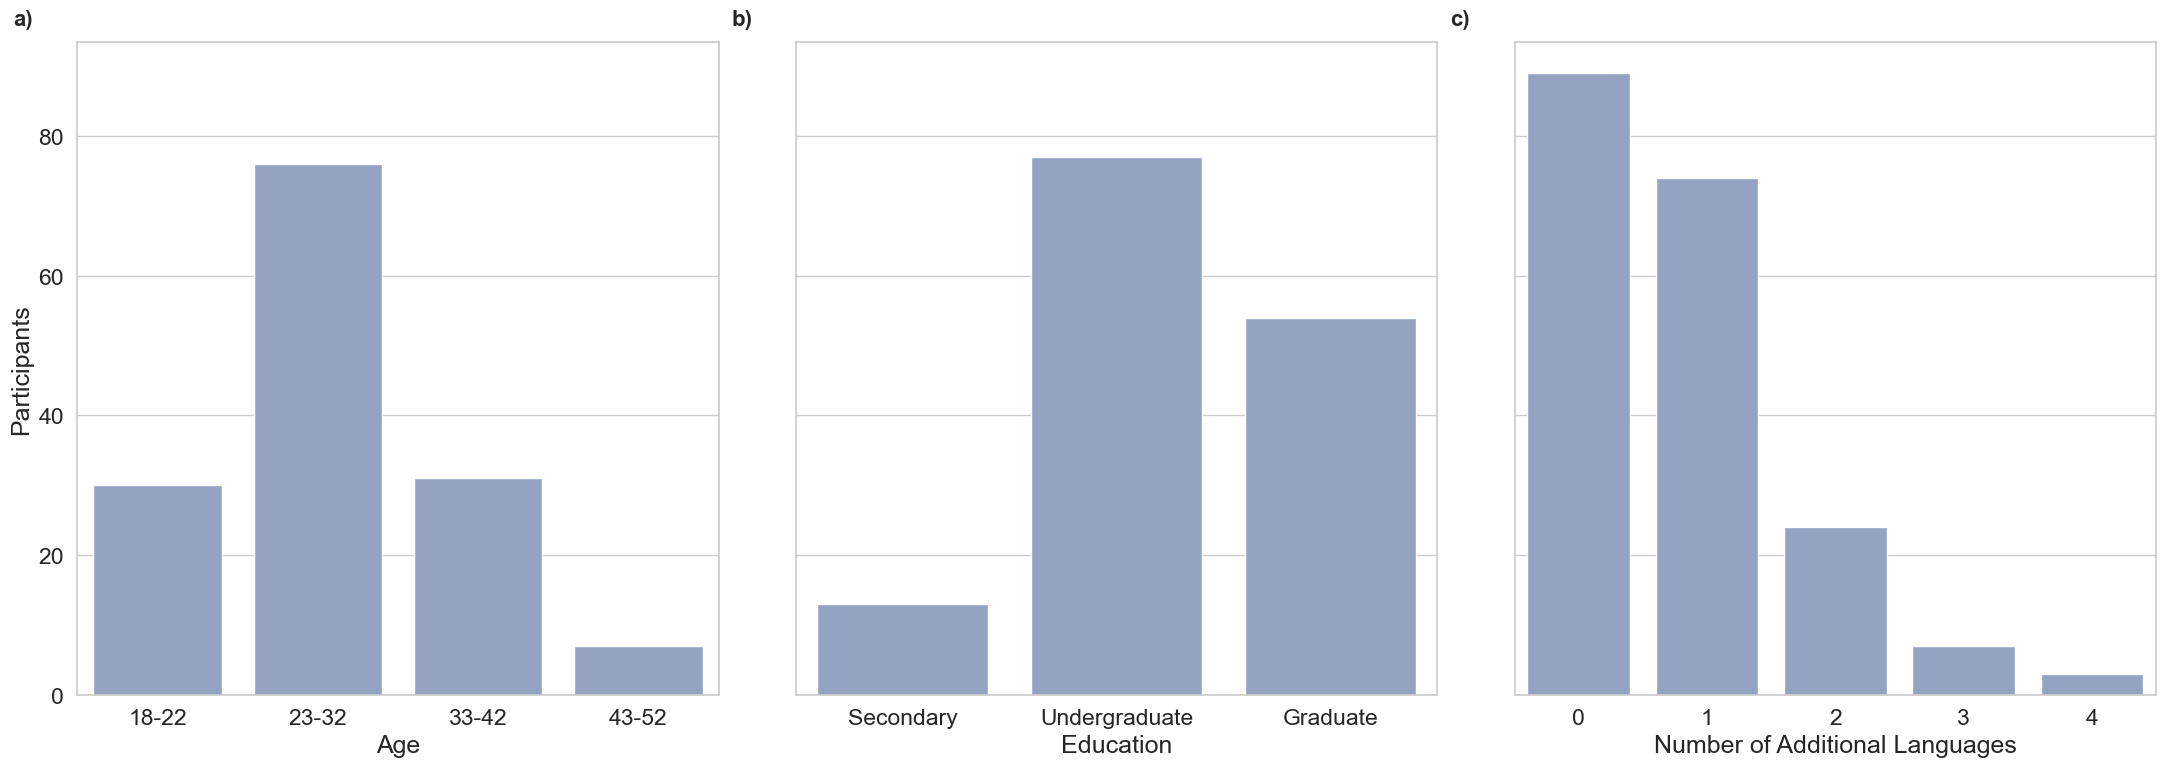

In [118]:
# Create Figure 1: Demographics
sns.set_context("paper", font_scale=2)
sns.set_theme(font_scale=1.5, style="whitegrid")
fig_colors = "#8da0cb"  # "#a1c9f4"
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 8), sharey="row")
sns.set_style("whitegrid")

# Plot 1: Countplot for Age
age_bins = [18, 22, 32, 42, 52]
age_labels = ["18-22", "23-32", "33-42", "43-52"]
data = questionnaire_df.copy()
data["age_category"] = pd.cut(
    data["Age"], bins=age_bins, labels=age_labels, right=False
)
sns.countplot(
    data=data, x="age_category", color=fig_colors, ax=axes[0], order=age_labels
)
axes[0].set(ylabel="Participants")
axes[0].set(xlabel="Age")

# Plot 2: Countplot for Level of Education
education_order = ["secondary", "college", "postgrad"]
education_labels = ["Secondary", "Undergraduate", "Graduate"]
sns.countplot(
    data=data, x="Education Level", color=fig_colors, ax=axes[1], order=education_order
)
axes[1].set(xticklabels=education_labels)
axes[1].set(ylabel="")
axes[1].set(xlabel="Education")

# Plot 3: Barplot for Number of Additional Languages
add_lang_labels = ["0", "1", "2", "3", "4", "5+"]
axes[2] = sns.barplot(
    x=list(num_of_lang_plus_5.keys()),
    y=list(num_of_lang_plus_5.values()),
    color=fig_colors,
    ax=axes[2],
)
axes[2].set(ylabel="")
axes[2].set(xlabel="Number of Additional Languages")
axes[2].set(xticklabels=add_lang_labels)

# Add labels (a, b, c) to each subplot
axes[0].text(
    -0.1,
    1.05,
    "a)",
    transform=axes[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)
axes[1].text(
    -0.1,
    1.05,
    "b)",
    transform=axes[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)
axes[2].text(
    -0.1,
    1.05,
    "c)",
    transform=axes[2].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

# Adjust layout
plt.tight_layout()

# Save the plot as pdf
plt.savefig(fig_save_path / "demographics.pdf")

# Show the plot
plt.show()

## 1.1.3 Calibration Quality

In [124]:
# mean number of calibration sessions during an experiment
session_interruptions = SESSION_SUMMARY["recalibration_count"]
print(f"Mean number of recalibrations: {round(np.mean(session_interruptions),1)}")

print(
    f"Recalibrations min - {SESSION_SUMMARY["recalibration_count"].min()}, \
    Recalibrations max - {SESSION_SUMMARY["recalibration_count"].max()}"
)

# mean number of calibration attempts per calibration session
mean_calibrations_per_session = sum(SESSION_SUMMARY["total_recalibrations"]) / sum(SESSION_SUMMARY["recalibration_count"])
print(f"Mean number of calibrations per-recalibration session: {round(mean_calibrations_per_session,1)}")

Mean number of recalibrations: 8.3
Recalibrations min - 0.0,     Recalibrations max - 34.0
Mean number of calibrations per-recalibration session: nan


In [75]:
# Percent validation error over 0.3
validation_error = pd.read_csv(config.BASE_PATH / "validation_error.csv")
over_03 = validation_error[["num_over_03", "total_trials"]].sum()

percentage_over_03 = round(over_03["num_over_03"] / over_03["total_trials"] * 100, 1)
percentage_avg_error_over_03 = round(
    (validation_error["avg_avg_val_error"] > 0.3).sum() / 360 * 100, 1
)

print(f"Percentage of Trials Over 0.3 Error: {percentage_over_03}%")
print(f"Percentage of Validation Errors Over 0.3: {percentage_avg_error_over_03}%")

ZeroDivisionError: division by zero

# 1.1.4 Experiment Duration

In [119]:
SESSION_SUMMARY.columns

Index(['participant_id', 'article_batch', 'list_number', 'question_preview',
       'data_collection_site', 'comprehension_score-regular_trials',
       'comprehension_score-repeated_reading', 'recalibration_count',
       'total_recalibrations', 'mean_validation_error',
       'total_session_duration', 'session_duration', 'dominant_eye',
       'tracked_eye', 'lextale_score'],
      dtype='object')

In [129]:
print(f'mean duration (in minutes) - {round(np.mean(SESSION_SUMMARY["session_duration"]),1)}')
print(f'mean total duration (in minutes) - {round(np.mean(SESSION_SUMMARY["total_session_duration"]),1)}')
print(f'total duration of eye movements recordings (in hours) - {round(np.sum(SESSION_SUMMARY["session_duration"])/60,1)}')

mean duration (in minutes) - 78.4
mean total duration (in minutes) - 102.5
total duration of eye movements recordings (in hours) - 179.1


In [121]:
hunting = SESSION_SUMMARY[SESSION_SUMMARY["question_preview"] == True]
gathering = SESSION_SUMMARY[SESSION_SUMMARY["question_preview"] == False]
h_session_duration = hunting["session_duration"]
g_session_duration = gathering["session_duration"]
print(f"mean hunting duration - {round(np.mean(h_session_duration),1)}")
print(f"mean gathering duration - {round(np.mean(g_session_duration),1)}")
h_total_session_duration = hunting["total_session_duration"]
g_total_session_duration = gathering["total_session_duration"]
print(f"total mean hunting duration - {round(np.mean(h_total_session_duration),1)}")
print(f"total mean gathering duration - {round(np.mean(g_total_session_duration),1)}")

mean hunting duration - 76.4
mean gathering duration - 79.7
total mean hunting duration - 98.7
total mean gathering duration - 104.9


In [122]:
# paragraph duration
ia_p = IA_P.drop_duplicates(subset=["RECORDING_SESSION_LABEL", "batch", "article_id", "paragraph_id", "reread"]) # change to "Participant ID"
ia_h_duration = ia_p[ia_p["batch_condition"] == "p"]
ia_g_duration = ia_p[ia_p["batch_condition"] == "n"]
ia_p = ia_p.groupby("RECORDING_SESSION_LABEL").sum()
ia_h_duration = ia_h_duration.groupby("RECORDING_SESSION_LABEL").sum()
ia_g_duration = ia_g_duration.groupby("RECORDING_SESSION_LABEL").sum()

print(f"mean p - {round((ia_p['PARAGRAPH_RT']/1000/60).mean(),1)}")
print(f"p hunting - {round((ia_h_duration['PARAGRAPH_RT']/1000/60).mean(),1)}")
print(f"p gathering - {round((ia_g_duration['PARAGRAPH_RT']/1000/60).mean(),1)}")
# q duration
print(f"mean q - {round((ia_p['QUESTION_RT']/1000/60).mean(),1)}")
print(f"q hunting - {round((ia_h_duration['QUESTION_RT']/1000/60).mean(),1)}")
print(f"q gathering - {round((ia_g_duration['QUESTION_RT']/1000/60).mean(),1)}")
# a duration
print(f"mean a - {round((ia_p['CONFIRM_FINAL_ANSWER_RT']/1000/60).mean(),1)}")
print(f"a hunting - {round((ia_h_duration['CONFIRM_FINAL_ANSWER_RT']/1000/60).mean(),1)}")
print(f"a gathering - {round((ia_g_duration['CONFIRM_FINAL_ANSWER_RT']/1000/60).mean(),1)}")
# q&a duration
print(f"mean qa - {round((ia_p['QUESTION_RT']/1000/60).mean() + (ia_p['CONFIRM_FINAL_ANSWER_RT']/1000/60).mean(),1)}")
print(f"qa hunting - {round((ia_h_duration['QUESTION_RT']/1000/60).mean() + (ia_h_duration['CONFIRM_FINAL_ANSWER_RT']/1000/60).mean(),1)}")
print(f"qa gathering - {round((ia_g_duration['QUESTION_RT']/1000/60).mean() + (ia_g_duration['CONFIRM_FINAL_ANSWER_RT']/1000/60).mean(),1)}")
# q_preview duration
print(f"q preview - {round((ia_h_duration['PREVIEW_QUESTION_RT']/1000/60).mean(),1)}")


mean p - 50.6
p hunting - 45.1
p gathering - 54.1
mean q - 3.7
q hunting - 3.1
q gathering - 4.2
mean a - 14.6
a hunting - 14.0
a gathering - 14.9
mean qa - 18.3
qa hunting - 17.1
qa gathering - 19.1
q preview - 6.2


# 1.1.5 Reading Comprehension Performance

In [131]:
# reading comprehension accuracy Hunting
comprehension_score = SESSION_SUMMARY.groupby(["question_preview"])["comprehension_score-regular_trials"].mean()
comprehension_hunting = comprehension_score[True]
# reading comprehension accuracy Gathering
comprehension_gathering = comprehension_score[False]

# reading comprehension accuracy re-reading Hunting
reread_comprehension_score = SESSION_SUMMARY.groupby(["question_preview"])["comprehension_score-repeated_reading"].mean()
reread_comprehension_hunting = reread_comprehension_score[True]
# reading comprehension accuracy re-reading Gathering
reread_comprehension_gathering = reread_comprehension_score[False]


print(
    f"Reading Comprehension Accuracy - Hunting (without reread): {comprehension_hunting.round(1)}"
)
print(
    f"Reading Comprehension Accuracy - Gathering (without reread): {comprehension_gathering.round(1)}"
)
print(
    f"Reading Comprehension Accuracy - Hunting (with reread): {reread_comprehension_hunting.round(1)}"
)
print(
    f"Reading Comprehension Accuracy - Gathering (with reread): {reread_comprehension_gathering.round(1)}"
)

Reading Comprehension Accuracy - Hunting (without reread): 75.7
Reading Comprehension Accuracy - Gathering (without reread): 75.6
Reading Comprehension Accuracy - Hunting (with reread): 75.9
Reading Comprehension Accuracy - Gathering (with reread): 79.8


Participants with missing Mich-Test: [1080. 1148. 1027.]
Participants with missing LEXTALE: [1148.]
Mean comprehension_score-regular_trials: 75.7max comprehension_score-regular_trials: 98.0min comprehension_score-regular_trials: 30.0midian comprehension_score-regular_trials: 79.0
Mean comprehension_score-repeated_reading: 78.4max comprehension_score-repeated_reading: 100.0min comprehension_score-repeated_reading: 20.0midian comprehension_score-repeated_reading: 83.0
Mean LEXTALE: 73.0max LEXTALE: 100.0min LEXTALE: 37.25midian LEXTALE: 73.0
Mean Mich-Test: 85.9max Mich-Test: 100.0min Mich-Test: 34.0midian Mich-Test: 92.0


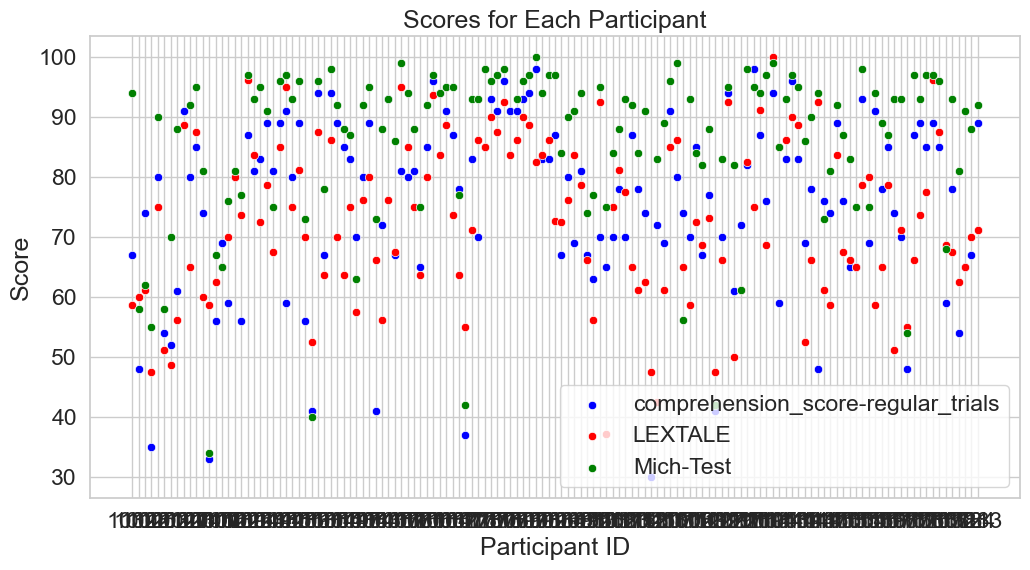

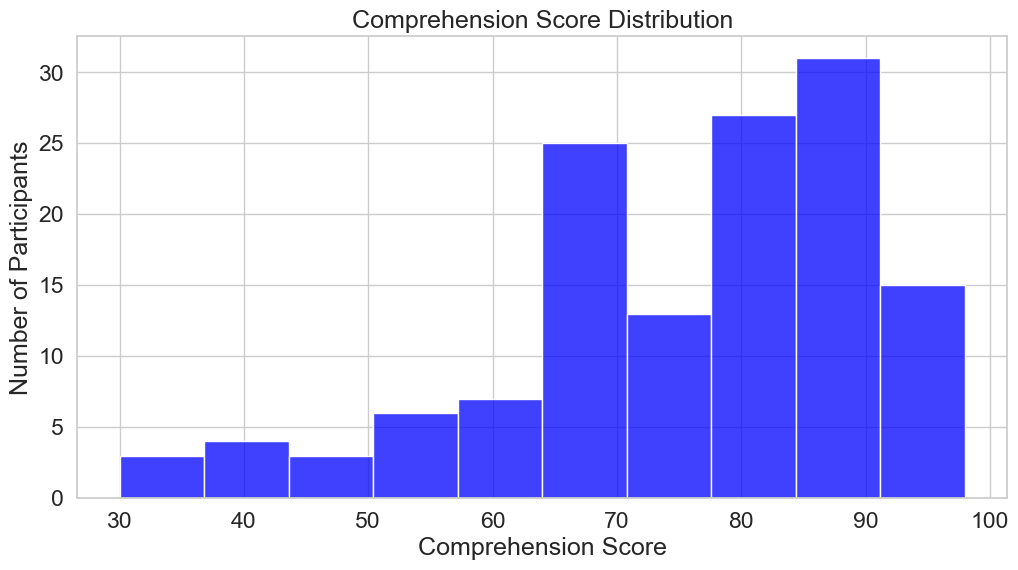

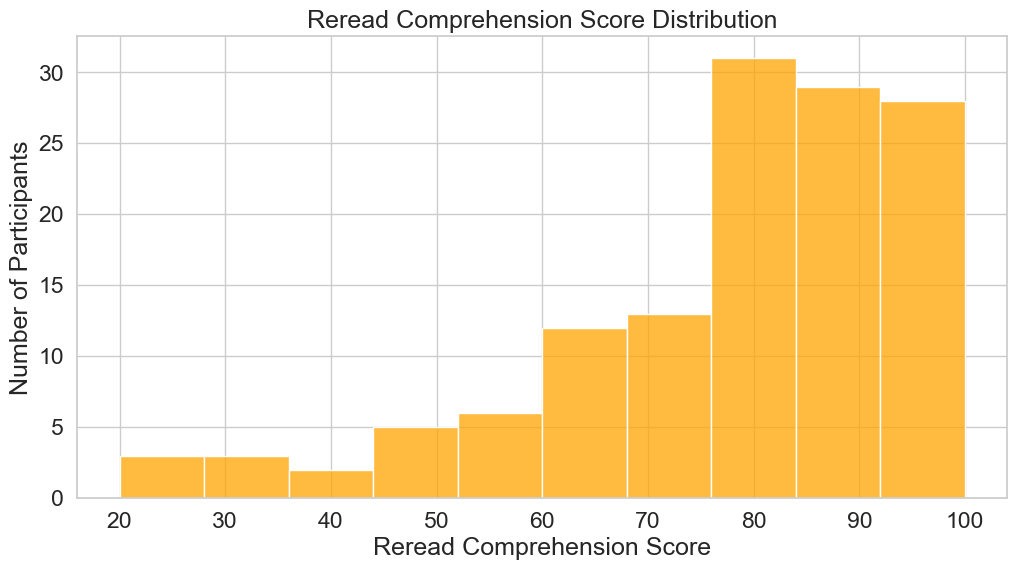

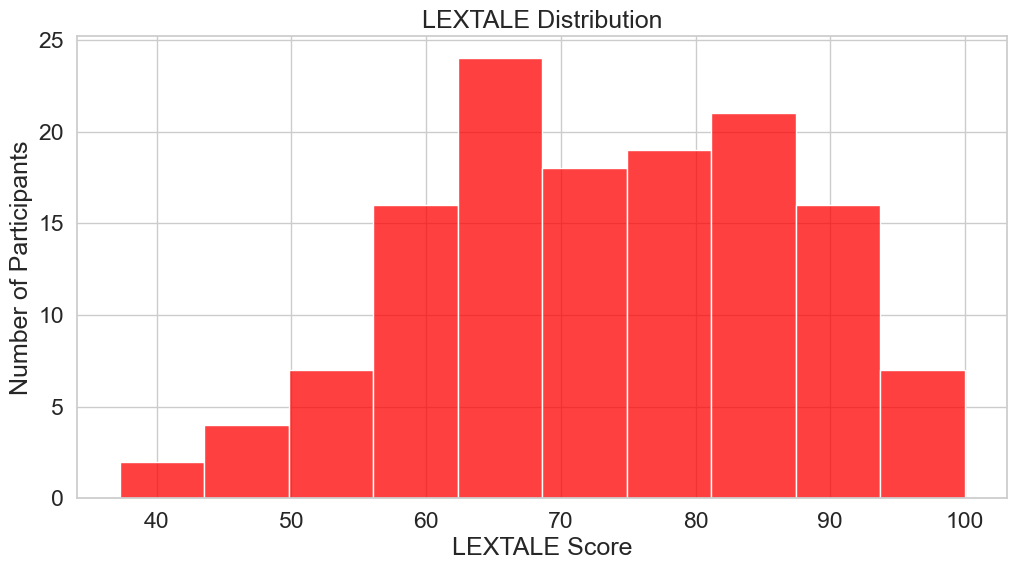

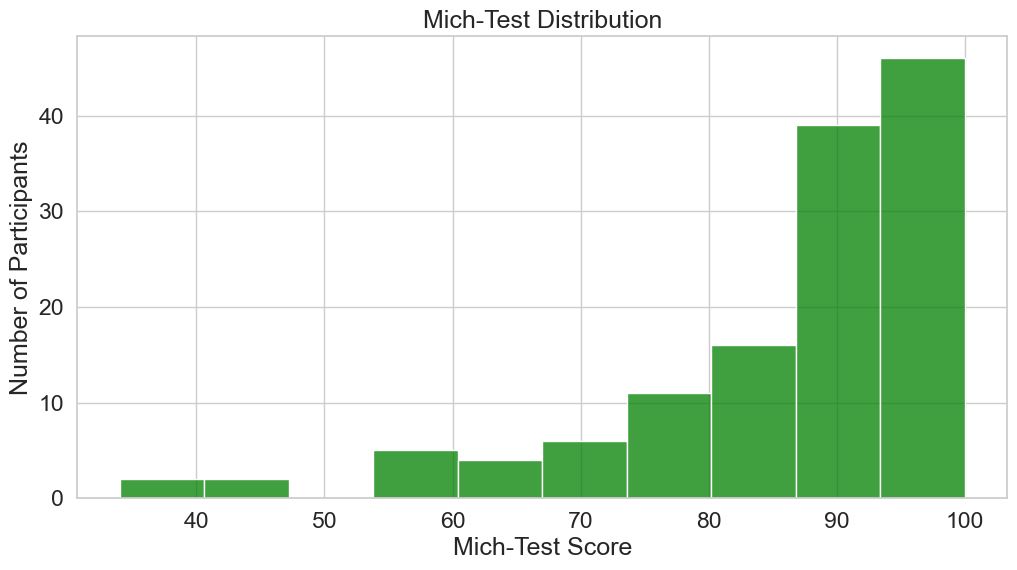

In [153]:
# print participants with missing mich-test
missing_mich_test = session_summary[session_summary["Mich-Test"].isnull()]
print(f"Participants with missing Mich-Test: {missing_mich_test['participant_id'].values}")

# print participants with missing LEXTALE
missing_LEXTALE = session_summary[session_summary["LEXTALE"].isnull()]
print(f"Participants with missing LEXTALE: {missing_LEXTALE['participant_id'].values}")


# if LEXTALE over 100 remove value from the dataframe
session_summary_135 = session_summary_135[session_summary_135["LEXTALE"] <= 100] 


# print the mean, max, min, midian of the comprehension_score-regular_trials, comprehension_score-repeated_reading, LEXTALE, Mich-Test
print(
    f"Mean comprehension_score-regular_trials: {session_summary_135['comprehension_score-regular_trials'].mean().round(1)}"
    f"max comprehension_score-regular_trials: {session_summary_135['comprehension_score-regular_trials'].max()}"
    f"min comprehension_score-regular_trials: {session_summary_135['comprehension_score-regular_trials'].min()}"
    f"midian comprehension_score-regular_trials: {session_summary_135['comprehension_score-regular_trials'].median()}"
)
print(
    f"Mean comprehension_score-repeated_reading: {session_summary_135['comprehension_score-repeated_reading'].mean().round(1)}"
    f"max comprehension_score-repeated_reading: {session_summary_135['comprehension_score-repeated_reading'].max()}"
    f"min comprehension_score-repeated_reading: {session_summary_135['comprehension_score-repeated_reading'].min()}"
    f"midian comprehension_score-repeated_reading: {session_summary_135['comprehension_score-repeated_reading'].median()}"
)
print(
    f"Mean LEXTALE: {session_summary_135['LEXTALE'].mean().round(1)}"
    f"max LEXTALE: {session_summary_135['LEXTALE'].max()}"
    f"min LEXTALE: {session_summary_135['LEXTALE'].min()}"
    f"midian LEXTALE: {session_summary_135['LEXTALE'].median()}"
)
# convert Mich-Test to numeric
session_summary_135["Mich-Test"] = pd.to_numeric(session_summary_135["Mich-Test"], errors="coerce")

print(
    f"Mean Mich-Test: {session_summary_135['Mich-Test'].mean().round(1)}"
    f"max Mich-Test: {session_summary_135['Mich-Test'].max()}"
    f"min Mich-Test: {session_summary_135['Mich-Test'].min()}"
    f"midian Mich-Test: {session_summary_135['Mich-Test'].median()}"
)


# plot a graph that for each participant (x-axis) shows 3 dots for score (y-axis): comprehension_score-regular_trials, LEXTALE, Mich-Test (map)
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=session_summary_135,
    x="participant_id",
    y="comprehension_score-regular_trials",
    color="blue",
    label="comprehension_score-regular_trials",
    ax=ax,

)
sns.scatterplot(
    data=session_summary_135,
    x="participant_id",
    y="LEXTALE",
    color="red",
    label="LEXTALE",
    ax=ax,
    # tilt the participant_id labels for better readability
)
sns.scatterplot(
    data=session_summary_135,
    x="participant_id",
    y="Mich-Test",
    color="green",
    label="Mich-Test",
    ax=ax,
)
ax.set_title("Scores for Each Participant")
ax.set_xlabel("Participant ID")
ax.set_ylabel("Score")
plt.legend()
plt.show()

# plot comprehension_score-regular_trials barplot destribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(session_summary_135["comprehension_score-regular_trials"], bins=10, color="blue", ax=ax)
ax.set_title("Comprehension Score Distribution")
ax.set_xlabel("Comprehension Score")
ax.set_ylabel("Number of Participants")
plt.show()

# plot comprehension_score-repeated_reading barplot destribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(session_summary_135["comprehension_score-repeated_reading"], bins=10, color="orange", ax=ax)
ax.set_title("Reread Comprehension Score Distribution")
ax.set_xlabel("Reread Comprehension Score")
ax.set_ylabel("Number of Participants")
plt.show()


# plot LEXTALE barplot destribution under 100
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(session_summary_135["LEXTALE"], bins=10, color="red", ax=ax)
ax.set_title("LEXTALE Distribution")
ax.set_xlabel("LEXTALE Score")
ax.set_ylabel("Number of Participants")
plt.show()

# plot Mich-Test barplot destribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(session_summary_135["Mich-Test"], bins=10, color="green", ax=ax)
ax.set_title("Mich-Test Distribution")
ax.set_xlabel("Mich-Test Score")
ax.set_ylabel("Number of Participants")
plt.show()


# Figure 2

TypeError: '<' not supported between instances of 'NoneType' and 'bool'

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


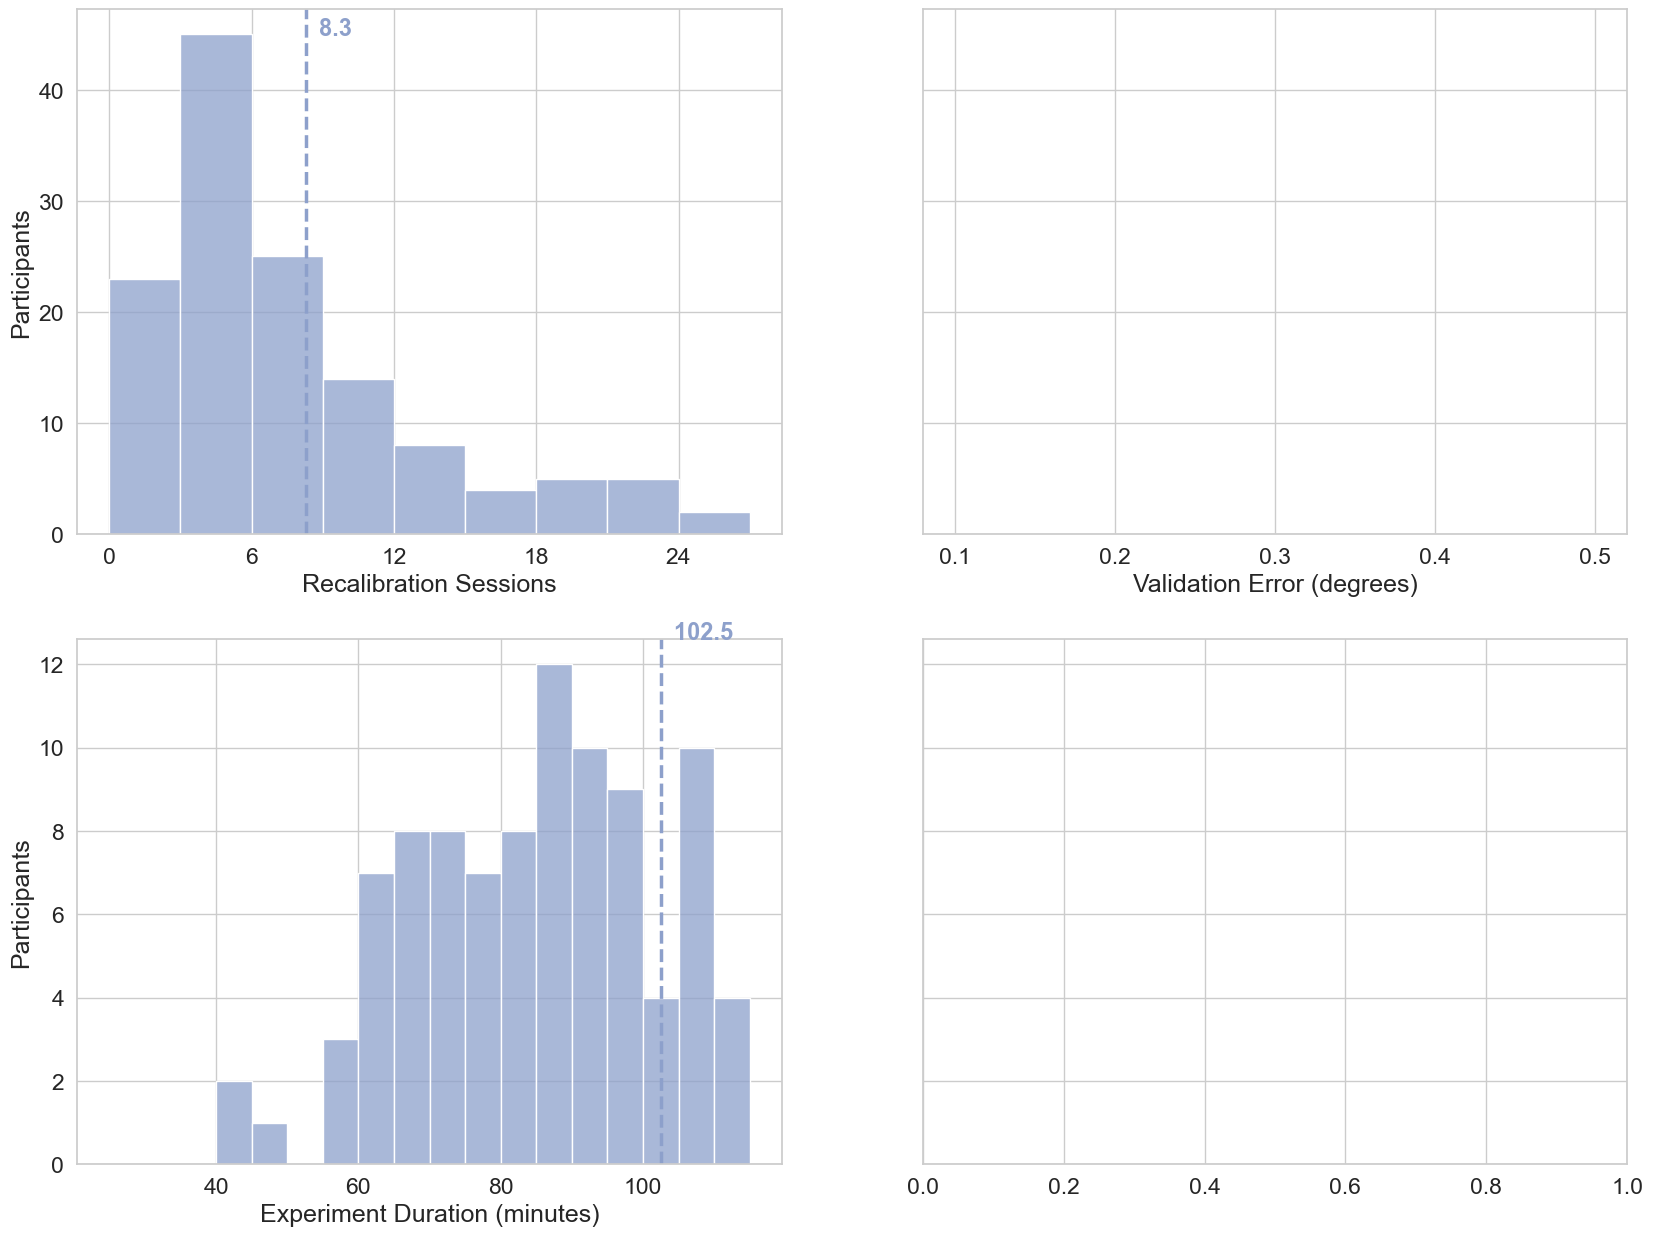

In [130]:
sns.set_context("paper", font_scale=2)
sns.set_theme(font_scale=1.5, style="whitegrid")
# Create Figure 2
fig_colors = "#8da0cb"
colors = ["#66c2a5", "#fc8d62"]
color_dict = {
    True: colors[0],
    False: colors[1],
}
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15), sharey="row")

data = SESSION_SUMMARY.copy()
# Plot 1: Number of Recalibrations
axes[0, 0] = sns.histplot(
    data,
    x="recalibration_count",
    color=fig_colors,
    ax=axes[0, 0],
    binrange=(0, 27),
    binwidth=3,
)
axes[0, 0].set(ylabel="Participants")
axes[0, 0].set(xlabel="Recalibration Sessions")
axes[0, 0].axvline(session_interruptions.mean(), color=fig_colors, ls="--", lw=2.5)
axes[0, 0].set_xticks(np.arange(0, 28, 6))

# Display mean value as text on the plot
axes[0, 0].text(
    session_interruptions.mean(),  # x-coordinate (same as mean value)
    axes[0, 0].get_ylim()[1] * 0.95,  # y-coordinate (adjust as needed)
    f"  {session_interruptions.mean():.1f}",  # Label text
    color=fig_colors,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

# Plot 2: Validations
axes[0, 1] = sns.histplot(
    data,
    x="mean_validation_error",
    color=fig_colors,
    ax=axes[0, 1],
    binrange=(0.1, 0.5),
    binwidth=0.025,
)
axes[0, 1].set(ylabel="")
axes[0, 1].set(xlabel="Validation Error (degrees)")
axes[0, 1].axvline(
    data["mean_validation_error"].mean(), color=fig_colors, ls="--", lw=2.5
)
axes[0, 1].set_xticks(np.arange(0.1, 0.51, 0.1))

axes[0, 1].text(
    data["mean_validation_error"].mean(), 
    axes[0, 1].get_ylim()[1] * 0.95, 
    f"  {data["mean_validation_error"].mean():.2f}", 
    color=fig_colors,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

# Plot 3: Experiment Duration
axes[1, 0] = sns.histplot(
    data,
    x="total_session_duration",
    color=fig_colors,
    ax=axes[1, 0],
    binrange=(25, 115),
    binwidth=5,
)
axes[1, 0].axvline(data["total_session_duration"].mean(), color=fig_colors, ls="--", lw=2.5)
axes[1, 0].set(ylabel="Participants")
axes[1, 0].set(xlabel="Experiment Duration (minutes)")

axes[1, 0].text(
    data["total_session_duration"].mean(),  
    axes[1, 0].get_ylim()[1] * 1,  
    f"  {data["total_session_duration"].mean():.1f}",  
    color=fig_colors,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

# Plot 4: Reading Comprehension Score
condition_labels = [
    "Hunting",
    "Gathering",
]

axes[1, 1] = sns.histplot(
    data=data,
    x="comprehension_score-regular_trials",
    palette=color_dict,
    ax=axes[1, 1],
    hue="question_preview",
    multiple="layer",
    binrange=(45, 100),
    binwidth=5,
)

axes[1, 1].legend(
    # handles=handles,
    labels=condition_labels,
    title="Condition",
    loc="upper left",
)
axes[1, 1].set(xlabel="Reading Comprehension Accuracy")
axes[1, 1].set(ylabel="")
axes[1, 1].axvline(
    comprehension_gathering,
    color=colors[1],
    ls="--",
    lw=2.5,
)

axes[1, 1].text(
    comprehension_gathering,
    axes[1, 1].get_ylim()[1] * 0.96,
    f"  {comprehension_gathering:.1f}",
    color=colors[1],
    ha="left",
    fontsize=17,
    fontweight="bold"
)

axes[1, 1].axvline(
    comprehension_hunting,
    color=colors[0],
    ls="--",
    lw=2.5,
)

axes[1, 1].text(
    comprehension_hunting,
    axes[1, 1].get_ylim()[1] * 0.96,
    f"  {comprehension_hunting:.1f}",
    color=colors[0],
    ha="left",
    fontsize=17,
    fontweight="bold"
)


# Add labels (a, b, c, d) to each subplot
axes[0, 0].text(
    -0.1,
    1.05,
    "a)",
    transform=axes[0, 0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)
axes[0, 1].text(
    -0.1,
    1.05,
    "b)",
    transform=axes[0, 1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)
axes[1, 0].text(
    -0.1,
    1.05,
    "c)",
    transform=axes[1, 0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)
axes[1, 1].text(
    -0.1,
    1.05,
    "d)",
    transform=axes[1, 1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

# increase font size
for ax in axes.flat:
    ax.tick_params(axis="both", which="major", labelsize=20)

# increase axis font size

# Set facecolor for the figure
fig.set_facecolor("white")

# Adjust layout
plt.tight_layout()

# Save the plot as pdf
plt.savefig(fig_save_path / "exp_stats.pdf")

# Show the plot
plt.show()

# 3.1 Textual Materials

In [ ]:
# Number of unique articles
unique_articles = onestop_qa.drop_duplicates(subset=["title"])
print(f"Total number of unique articles: {len(unique_articles)}")

Total number of unique articles: 30


In [ ]:
# Number of unique paragraphs
unique_paragraphs = onestop_qa.drop_duplicates(subset=["paragraph"]).query("level!=1")
number_of_paragraphs = len(unique_paragraphs) / 2
print(f"Total number of unique paragraphs: {number_of_paragraphs}")

Total number of unique paragraphs: 162.0


In [ ]:
# Calculate mean number of words per level
n_words = (
    onestop_qa.drop_duplicates(subset=["paragraph"])
    .query("level!=1")
    .groupby("level")["paragraph"]
    .apply(lambda x: x.str.split().str.len().sum())
)

print("Mean number of words per level:")
print(f"Advanced (level 0): {round(n_words[0], 1)}")
print(f"Elementary (level 2): {round(n_words[2], 1)}")

Mean number of words per level:
Advanced (level 0): 19425
Elementary (level 2): 15737


In [ ]:
# Advanced word tokens
adv_qa = unique_paragraphs[unique_paragraphs["level"] == 0]
adv_qa_words = [
    word
    for paragraph in utils.get_number_of_tokens(adv_qa, "paragraph")
    for word in paragraph
]

adv_sentences = [
    sen
    for paragraph in utils.get_number_of_tokens(adv_qa, "paragraph")
    for sen in paragraph
    if "." in sen
]

print(f"OneStopQA Advanced Words Count: {len(adv_qa_words)}")
print(
    f"mean paragraph length (words): {round(len(adv_qa_words) / number_of_paragraphs,1)}"
)
print(
    f"mean sentence length (words): {round(len(adv_qa_words) / len(adv_sentences),1)}"
)

OneStopQA Advanced Words Count: 19425
mean paragraph length (words): 119.9
mean sentence length (words): 20.8


In [ ]:
# Elementary word tokens
ele_qa = unique_paragraphs[unique_paragraphs["level"] == 2]
ele_qa_words = [
    word
    for paragraph in utils.get_number_of_tokens(ele_qa, "paragraph")
    for word in paragraph
]

ele_sentences = [
    sen
    for paragraph in utils.get_number_of_tokens(ele_qa, "paragraph")
    for sen in paragraph
    if "." in sen
]
print(f"OneStopQA Elementary Words Count: {len(ele_qa_words)}")
print(
    f"mean paragraph length (words): {round(len(ele_qa_words) / number_of_paragraphs,1)}"
)
print(
    f"mean sentence length (words): {round(len(ele_qa_words) / len(ele_sentences),1)}"
)

OneStopQA Elementary Words Count: 15737
mean paragraph length (words): 97.1
mean sentence length (words): 17.0


In [ ]:
def count_sentences(paragraph):
    """
    Count the number of sentences in a given paragraph.

    Args:
        paragraph (str): The text to analyze

    Returns:
        int: Number of sentences found

    Note: Considers '.', '!', and '?' as sentence endings.
    """
    if not isinstance(paragraph, str):
        raise TypeError("Input must be a string")

    if not paragraph.strip():
        return 0

    # Split on common sentence endings
    sentence_endings = [
        ". ",
        "! ",
        "? ",
        ".\n",
        "!\n",
        "?\n",
        ".” ",
        "!” ",
        "?” ",
        ".”\n",
        "!”\n",
        "?”\n",
    ]
    count = 0

    # Handle the case where the paragraph ends without space
    if paragraph.strip()[-1] in ".!?”":
        count = 1

    for ending in sentence_endings:
        count += paragraph.count(ending)


    return count

In [ ]:
def analyze_text_series(series):
    """
    Analyze a pandas series containing text data.
    
    Args:
        series (pd.Series): Series containing text data
        
    Returns:
        pd.DataFrame: DataFrame with text analysis metrics
    """
    # Count sentences for each row
    sentence_counts = series.apply(count_sentences)
    
    # Count words for each row
    word_counts = series.str.split().str.len()
    
    # Calculate average sentence length (words per sentence)
    avg_sentence_length = word_counts / sentence_counts
    
    # Create results DataFrame
    results = pd.DataFrame({
        'text': series,
        'sentence_count': sentence_counts,
        'word_count': word_counts,
        'avg_words_per_sentence': avg_sentence_length.round(2)
    })
    
    return results

In [ ]:
res_0 = analyze_text_series(unique_paragraphs.query('level==0')['paragraph'])
res_2 = analyze_text_series(unique_paragraphs.query('level==2')['paragraph'])
print(f"Mean sentences per paragraph in Advanced: {round(res_0.sentence_count.mean(), 2)}")
print(f"Mean sentences per paragraph in Elementary: {round(res_2.sentence_count.mean(), 2)}")

Mean sentences per paragraph in Advanced: 5.77
Mean sentences per paragraph in Elementary: 5.75


In [ ]:
# Calculate total words and sentences for level 0
total_words_0 = res_0['word_count'].sum()
total_sentences_0 = res_0['sentence_count'].sum()
avg_words_per_sentence_0 = round(total_words_0 / total_sentences_0, 1)

# Calculate total words and sentences for level 2
total_words_2 = res_2['word_count'].sum()
total_sentences_2 = res_2['sentence_count'].sum()
avg_words_per_sentence_2 = round(total_words_2 / total_sentences_2, 1)

print(f"Level 0 average words per sentence: {avg_words_per_sentence_0}")
print(f"Level 2 average words per sentence: {avg_words_per_sentence_2}")

Level 0 average words per sentence: 20.8
Level 2 average words per sentence: 16.9


In [ ]:
# Number of unique questions
onsqa_q = onestop_qa.drop_duplicates(subset=["paragraph_index", "question"])
onsqa_q_words = onsqa_q["question"]

print(f"Number of unique questions in OneStopQA: {len(onsqa_q)}")
print(
    f"Average length of questions in OneStopQA: {round(utils.get_average_length(onsqa_q_words),1)}"
)

Number of unique questions in OneStopQA: 486
Average length of questions in OneStopQA: 9.9


In [ ]:
# number of unique answers
onestop_qa["answers_tuple"] = onestop_qa["answers"].apply(tuple)
onsqa_a = onestop_qa.drop_duplicates(subset=["question", "answers_tuple"])
onsqa_a = onsqa_a.drop(columns=["answers_tuple"])
answers_df = pd.DataFrame(onsqa_a["answers"].tolist(), columns=["a", "b", "c", "d"])
onsqa_a = onsqa_a.reset_index(drop=True)
onsqa_a = pd.concat([onsqa_a, answers_df], axis=1)
a = onsqa_a["a"].tolist()
b = onsqa_a["b"].tolist()
c = onsqa_a["c"].tolist()
d = onsqa_a["d"].tolist()
unique_answers = a + b + c + d

print(f"Total Unique Answers: {len(onsqa_a)}")
print(f"Mean Length of 'a': {round(utils.get_average_length(a),1)}")
print(f"Mean Length of 'b': {round(utils.get_average_length(b),1)}")
print(f"Mean Length of 'c': {round(utils.get_average_length(c),1)}")
print(f"Mean Length of 'd': {round(utils.get_average_length(d),1)}")
print(
    f"Mean Length of All Unique Answers: {round(utils.get_average_length(unique_answers),1)}"
)

Total Unique Answers: 486
Mean Length of 'a': 7.1
Mean Length of 'b': 7.5
Mean Length of 'c': 7.9
Mean Length of 'd': 6.8
Mean Length of All Unique Answers: 7.3


In [ ]:
# mean length of the critical span (a_span)
onsqa_a_span = unique_paragraphs["a_span"]
total_words_a = []
for a in onsqa_a_span:
    words = a[1] - a[0] + 1
    total_words_a.append(words)
mean_a = sum(total_words_a) / len(total_words_a)
print(f"Mean Length of Critical Span (a_span): {round(mean_a,1)}")
# mean length of the distractor span (d_span)
onsqa_d_span = unique_paragraphs["d_span"]
total_words_d = []
for d in onsqa_d_span:
    words = d[1] - d[0] + 1
    total_words_d.append(words)
mean_d = sum(total_words_d) / len(total_words_d)
print(f"Mean Length of Distractor Span (d_span): {round(mean_d,1)}")

Mean Length of Critical Span (a_span): 31.6
Mean Length of Distractor Span (d_span): 12.9


# 3.3 Participants

In [ ]:
# participants recruited from:
data_collection_sites = session_summary["data_collection_site"].value_counts()
print(data_collection_sites)

data_collection_site
MIT         74
Technion    62
Name: count, dtype: int64


In [ ]:
questionnaire_df['Participant ID'] = questionnaire_df['Participant ID'].astype(int)
metadata = SESSION_SUMMARY.merge(questionnaire_df, left_on="participant_id", right_on="Participant ID")	
metadata_gathering = metadata[metadata['question_preview']==False]
print(f"Mean AoA of Gathering participants: {metadata_gathering['English AoA'].mean().round(1)}")

KeyError: 'Participant ID'

In [132]:
uni_affiliation = sum(metadata_gathering["University Affiliation"] == "yes")
print(f"Number of participants with university affiliation: {uni_affiliation}")
print(f"In percent: {round(uni_affiliation/len(metadata_gathering)*100,1)}%")

NameError: name 'metadata_gathering' is not defined

In [ ]:
print(f"Mean Age of Gathering participants: {metadata_gathering.Age.mean().round(1)}")

Mean Age of Gathering participants: 23.4
